In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/My Drive/Spring25_Semester/IS_296/IS296_Collab/PI

/content/drive/My Drive/Spring25_Semester/IS_296/IS296_Collab/PI


In [ ]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [ ]:
tbl = Table.read_table('/content/drive/My Drive/Spring25_Semester/IS_296/IS296_Collab/PI/BHuynh_Personal_Informatics.csv')
tbl

WeekID,day ID,DayOfWeek,date,Time Exercising (Min),Time Studying (Min),"Emotion (0 = low, 1 = med, 2 = high)",Time Reading (Min),"Sleep (Over 8 hours = 1, Under 8 hours = 0)",Number of Diary Entries
0,1,Mon,2/10/2025,32,150,0,29,0,0
0,2,Tue,2/11/2025,82,90,1,30,1,0
0,3,Wed,2/12/2025,24,30,1,20,1,1
0,4,Thu,2/13/2025,115,30,2,5,1,0
0,5,Fri,2/14/2025,0,0,0,0,0,0
0,6,Sat,2/15/2025,0,0,2,0,1,0
0,7,Sun,2/16/2025,21,90,1,0,1,0
1,8,Mon,2/17/2025,53,200,2,0,1,1
1,9,Tue,2/18/2025,46,30,1,30,1,0
1,10,Wed,2/19/2025,112,45,0,0,0,0


### **Q1.** How many days did you recorrd?

In [ ]:
days = tbl.num_rows
days

42

### **Q2.** List the variables you recorded.

In [ ]:
tbl.labels

('WeekID',
 'day ID',
 'DayOfWeek',
 'date',
 'Time Exercising (Min) ',
 'Time Studying (Min)',
 'Emotion (0 = low, 1 = med, 2 = high)',
 'Time Reading (Min) ',
 'Sleep (Over 8 hours = 1, Under 8 hours = 0) ',
 'Number of Diary Entries ')

### **Q3.** What percentage of data was recorded over weekends?


In [ ]:
sat = tbl.where('DayOfWeek', 'Sat').num_rows
sun = tbl.where('DayOfWeek', 'Sun').num_rows
weekend_days = sat + sun
percentage = weekend_days/days * 100
print(round(percentage, 2),'%')

28.57 %


### **Q4a.** What is my daily average exercise minutes?  


In [ ]:
tbl.select('DayOfWeek', 'Time Exercising (Min) ').group('DayOfWeek', np.average)\
.sort('Time Exercising (Min)  average', descending=True)

DayOfWeek,Time Exercising (Min) average
Tue,65.5
Wed,50.8333
Thu,48.6667
Mon,37.3333
Sun,22.5
Fri,15.5
Sat,13.1667


### **Q4b.** Which days did I have the highest Emotion score?



In [ ]:
tbl.pivot('Emotion (0 = low, 1 = med, 2 = high)', 'DayOfWeek')\
.sort('2', descending=True)

DayOfWeek,0,1,2
Sat,0,2,4
Fri,1,3,2
Mon,2,2,2
Thu,0,4,2
Sun,2,4,0
Tue,0,6,0
Wed,3,3,0


The data shows that Saturdays are my happiest days!

### **Q4c.** How do Exercise minutes relate to my Emotion Score?

In [ ]:
tbl.pivot('Emotion (0 = low, 1 = med, 2 = high)','Time Exercising (Min) ')\
.sort('Time Exercising (Min) ',descending=True).show()

Time Exercising (Min),0,1,2
115,0,0,1
113,0,1,0
112,1,0,0
100,0,1,0
84,0,1,0
83,0,1,0
82,0,1,0
78,0,2,0
69,0,0,1
54,0,2,0


Overall, the days that I exercised over 30 minutes, I had an Emotion score of 1 or 2. The days that I exercised under 30 min, I was more likely to have an Emotion score of 0 or 1. This proves that more exercise does boost my mood!

### **Q4d.** How do my Reading minutes affect my Sleep?

In [ ]:
tbl.pivot('Sleep (Over 8 hours = 1, Under 8 hours = 0) ','Time Reading (Min) ')

Time Reading (Min),0,1
0,6,17
5,0,1
10,0,2
15,1,2
20,0,3
29,1,0
30,0,9


Overall, the days where I read, I slept for over 8 hours. Reading does help my sleep!

### **Q5.** Create a plot to show the distribution of a variable of your choice.

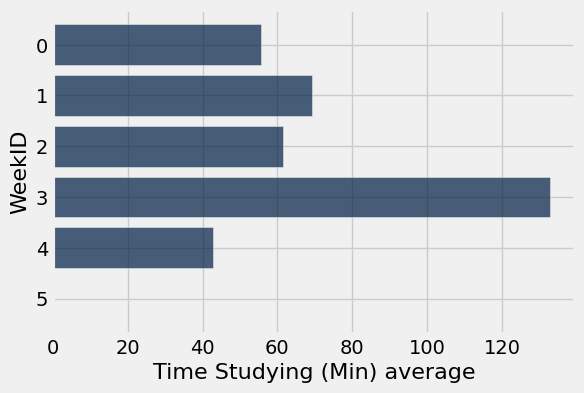

In [ ]:
tbl.select('Time Studying (Min)','WeekID').group('WeekID', np.average)\
.barh('WeekID')

### **Q6.** Create a plot to show the trend of a variable of your choice.

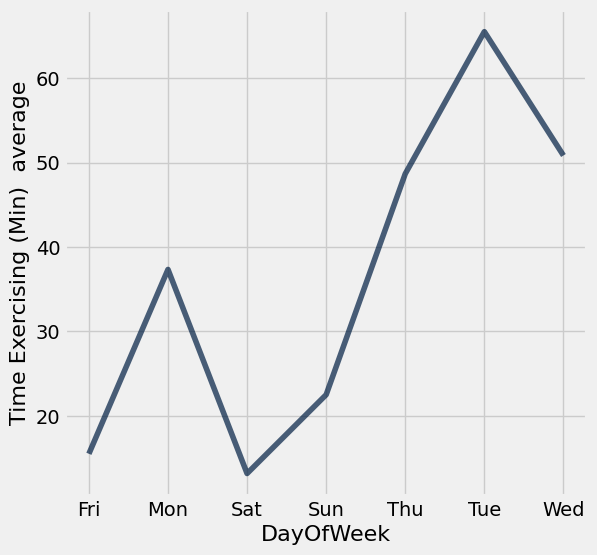

In [ ]:
tbl.select('DayOfWeek', 'Time Exercising (Min) ').group('DayOfWeek', np.average)\
.plot('DayOfWeek')

(I don't know how to sort the days of the week by order.)

### **Q7.** Create a plot to show to illustrate the relationship between two numeric variables.

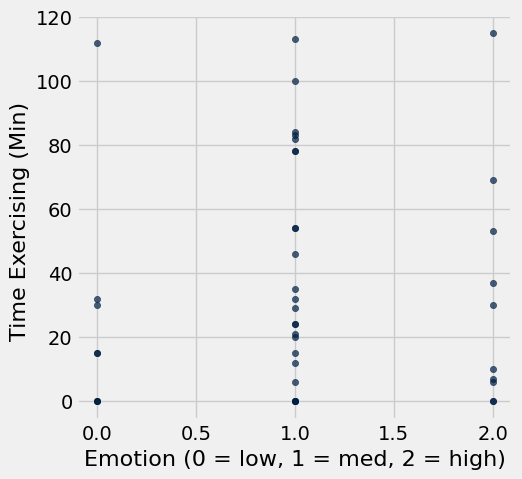

In [ ]:
tbl.scatter('Emotion (0 = low, 1 = med, 2 = high)', 'Time Exercising (Min) ')